# 🏦 Credit Risk Classification

## Project Overview

This project tackles a real-world binary classification problem:  
**predicting whether a loan applicant will default or not.**

The dataset contains applicant demographics, loan details, and credit history.  
The goal is to build a robust ML pipeline that handles messy data, class imbalance, and model selection.

### Pipeline Summary
- **Data Cleaning** — missing values, outliers, age filtering  
- **EDA** — distributions, correlations, categorical breakdowns  
- **Feature Engineering** — derived financial indicators & risk score  
- **Encoding & Scaling** — OHE, ordinal mapping, StandardScaler  
- **Model Comparison** — 6 models evaluated on Accuracy, F1, ROC-AUC  
- **Tuning** — GridSearchCV on XGBoost  
- **Imbalance Handling** — SMOTE resampling

## 1. Libraries & Setup

Importing the core libraries for data manipulation, visualization, preprocessing and classification.

In [38]:
import warnings, heapq
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler , RobustScaler
from sklearn.model_selection import (train_test_split,
                                     cross_val_score,
                                     GridSearchCV)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve
)
import joblib


## 2. Loading the Dataset

Loading the credit_risk_dataset which contains behavioral data for 32581 active credit card 

In [2]:
df=pd.read_csv("credit_risk_dataset.csv")
df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


## 3. Exploratory Data Analysis (EDA)

Before building any model, we explore the dataset structure, check for missing values, duplicates, and understand the distribution of each feature.

In [3]:
df.shape

(32581, 12)

In [4]:
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [5]:
df.tail()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26
32580,66,42000,RENT,2.0,MEDICAL,B,6475,9.99,0,0.15,N,30


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [7]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [8]:
columns=df.columns
pd.set_option('display.max_rows', None)
for i in columns:
    print(df[i].value_counts())
    print('-----------------------')

person_age
23     3889
22     3633
24     3549
25     3037
26     2477
27     2138
28     1854
29     1687
30     1316
21     1229
31     1142
32      964
33      856
34      709
35      620
36      548
37      478
38      373
39      302
40      271
41      241
42      188
43      164
44      141
45      108
46       94
47       94
48       75
50       52
49       49
51       39
52       36
53       30
54       24
55       20
58       19
56       15
57       15
20       15
60       15
65        9
66        9
61        9
70        7
64        7
62        7
59        5
69        5
144       3
73        3
63        3
123       2
78        1
94        1
80        1
84        1
76        1
67        1
Name: count, dtype: int64
-----------------------
person_income
60000      1046
30000       847
50000       778
40000       658
45000       590
75000       579
48000       532
65000       532
70000       527
42000       524
36000       518
55000       471
80000       448
54000       444
35000

In [9]:
pd.set_option('display.max_rows', None)
df["person_age"].value_counts()

person_age
23     3889
22     3633
24     3549
25     3037
26     2477
27     2138
28     1854
29     1687
30     1316
21     1229
31     1142
32      964
33      856
34      709
35      620
36      548
37      478
38      373
39      302
40      271
41      241
42      188
43      164
44      141
45      108
46       94
47       94
48       75
50       52
49       49
51       39
52       36
53       30
54       24
55       20
58       19
56       15
57       15
20       15
60       15
65        9
66        9
61        9
70        7
64        7
62        7
59        5
69        5
144       3
73        3
63        3
123       2
78        1
94        1
80        1
84        1
76        1
67        1
Name: count, dtype: int64

### 3.1 Handling Missing Values AND Age Groubing

**Missing Values:**
- `loan_int_rate` — imputed using **median per loan grade** (grade-correlated)
- `person_emp_length` — imputed using **median per age group**

**Age Grouping:**
- Created `age_group` bins: Young / Early_Adult / Mid_Adult / Senior / Old  
  (used for smarter imputation and later as an engineered feature)

**Change Wrong Data**

In [10]:
df=df[df["person_age"]<=84]

In [11]:
df['age_group'] = pd.cut(
    df['person_age'],
    bins=[18, 25, 35, 50, 65, 84],
    labels=['Young', 'Early_Adult', 'Mid_Adult', 'Senior', 'Old']
)

In [12]:
df['loan_int_rate'] = df.groupby('loan_grade')['loan_int_rate'].transform(lambda x: x.fillna(x.median()))
df['person_emp_length']=df.groupby('age_group')['person_emp_length'].transform(lambda x: x.fillna(x.median()))

In [13]:
df["person_emp_length"].value_counts()

person_emp_length
0.0      4105
2.0      3848
4.0      3763
3.0      3460
5.0      2946
1.0      2914
6.0      2666
7.0      2195
8.0      1687
9.0      1367
11.0      740
10.0      696
12.0      574
13.0      426
14.0      335
15.0      238
16.0      165
17.0      129
18.0      104
19.0       64
20.0       42
21.0       38
22.0       19
24.0       10
23.0       10
25.0        8
26.0        6
27.0        5
31.0        4
28.0        3
123.0       2
30.0        2
41.0        1
34.0        1
29.0        1
38.0        1
Name: count, dtype: int64

In [14]:
df[df["person_emp_length"]==123.0] 

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3,Young
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4,Young


In [15]:
young_mean = df[df['age_group'] == 'Young']['person_emp_length'].mean()
df.loc[df['person_emp_length'] == 123.0, 'person_emp_length'] = young_mean

### 3.2 Outlier Detection

Using the IQR method to detect outliers across all numeric columns, followed by boxplots for visual inspection. Many financial features  naturally exhibit extreme values due to varying customer spending behaviors.

In [16]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

outliers_summary = {}

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]

    outliers_summary[col] = len(outliers)

print(outliers_summary)

{'person_age': 1488, 'person_income': 1481, 'person_emp_length': 851, 'loan_amnt': 1689, 'loan_int_rate': 6, 'loan_status': 7108, 'loan_percent_income': 651, 'cb_person_cred_hist_length': 1140}


### 3.3 Feature Distributions

Explored distributions and relationships in the data:

- **Histograms & Boxplots** — revealed right-skewed distributions for `person_income` and `loan_amnt` → applied `log1p` transformation
- **Countplots** — categorical features broken down by `loan_status` to spot patterns
- **Correlation Heatmap** — identified multicollinearity and key predictors

Text(0.5, 1.0, 'loan amount')

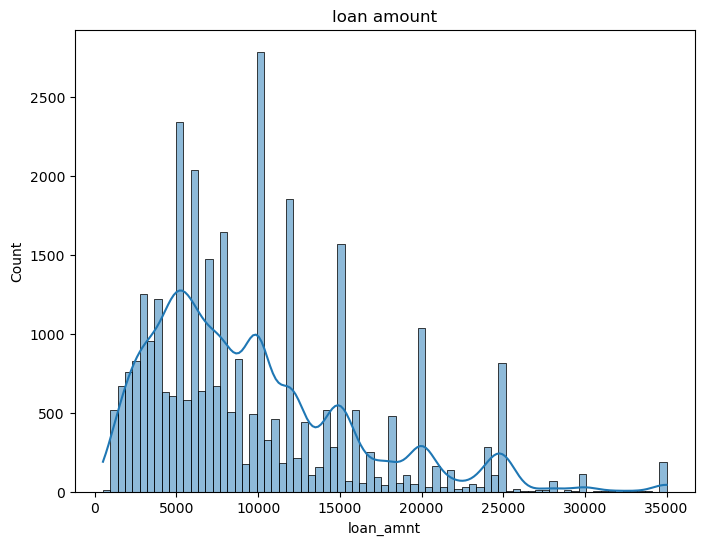

In [17]:
  plt.figure(figsize=(8,6))
  sns.histplot(df["loan_amnt"],kde=True)
  plt.title("loan amount")

Text(0.5, 1.0, 'income')

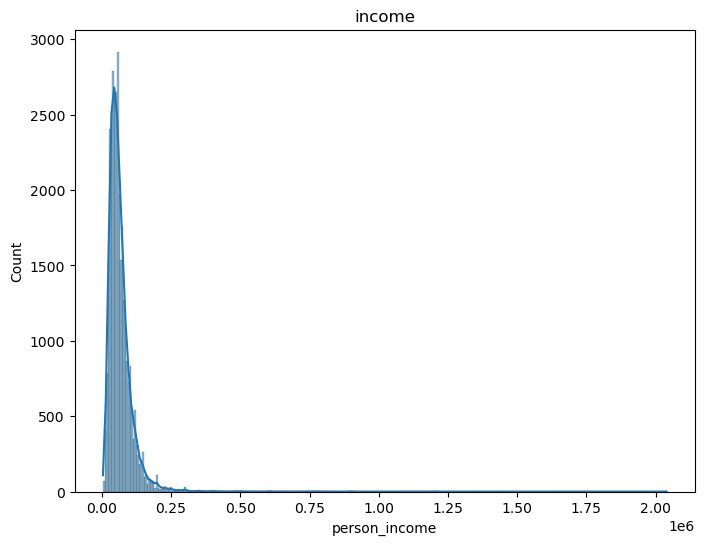

In [18]:
  plt.figure(figsize=(8,6))
  sns.histplot(df["person_income"],kde=True)
  plt.title("income")

In [19]:
df["person_income"]=np.log1p(df["person_income"])
df["loan_amnt"]=np.log1p(df["loan_amnt"])

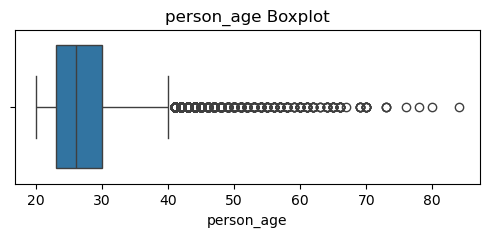

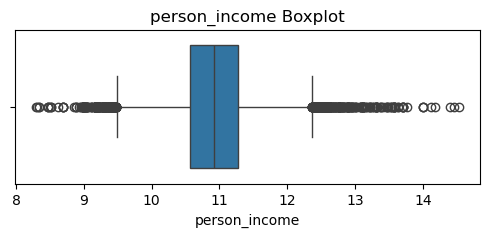

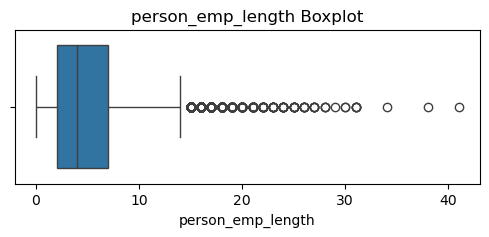

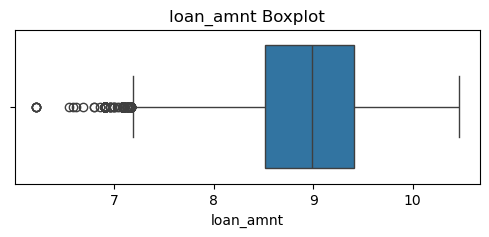

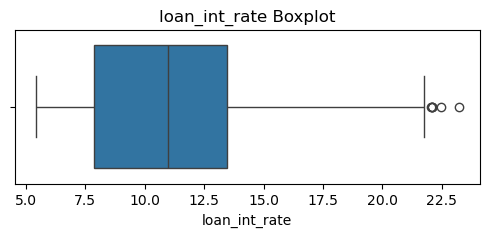

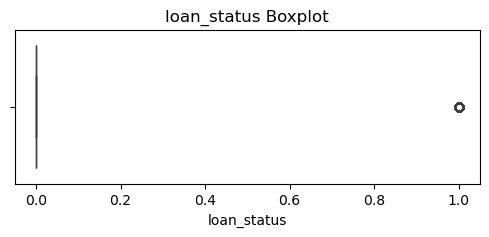

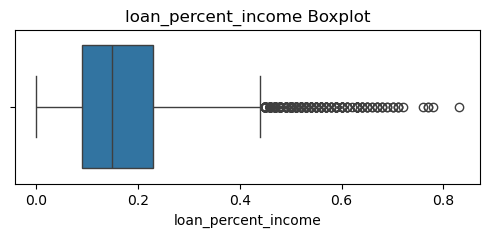

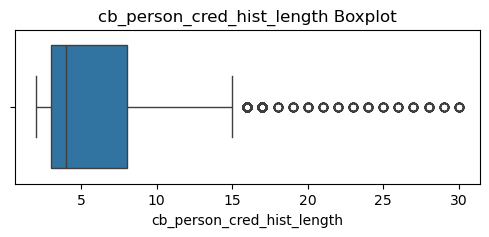

In [20]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(f"{col} Boxplot")



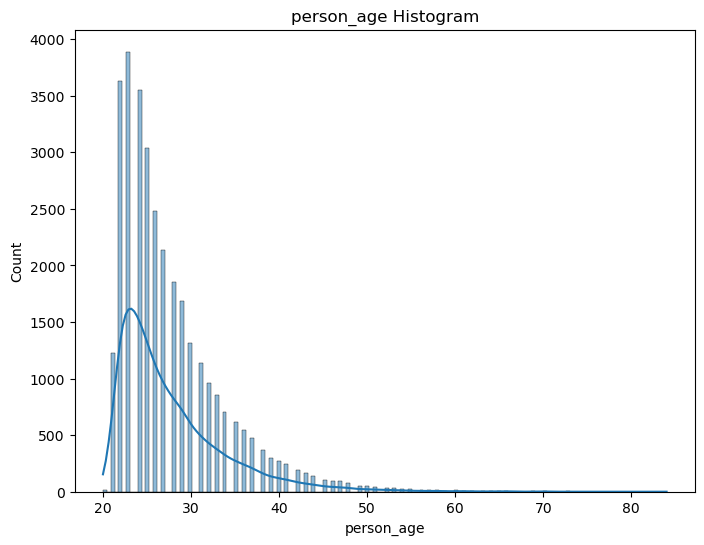

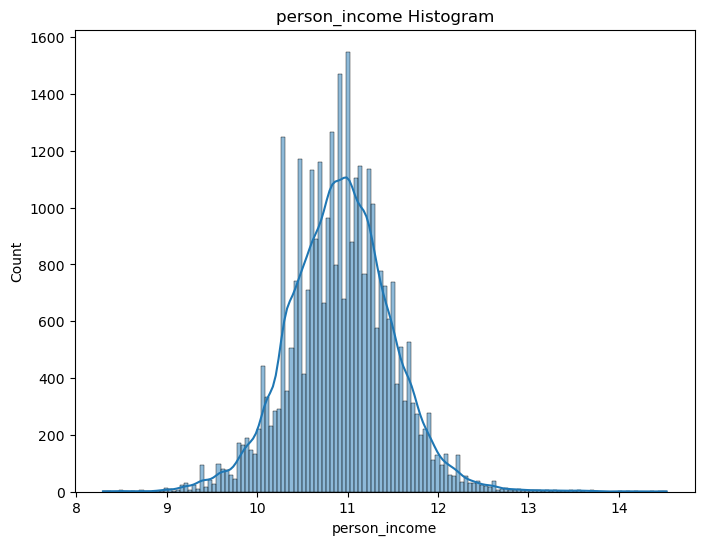

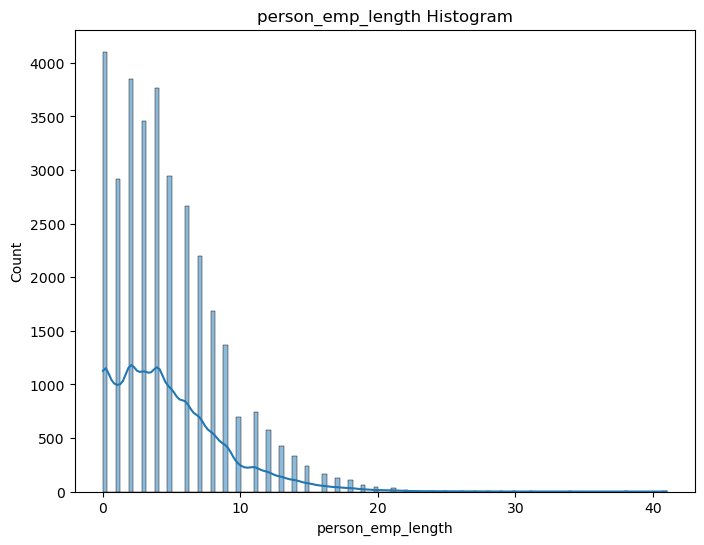

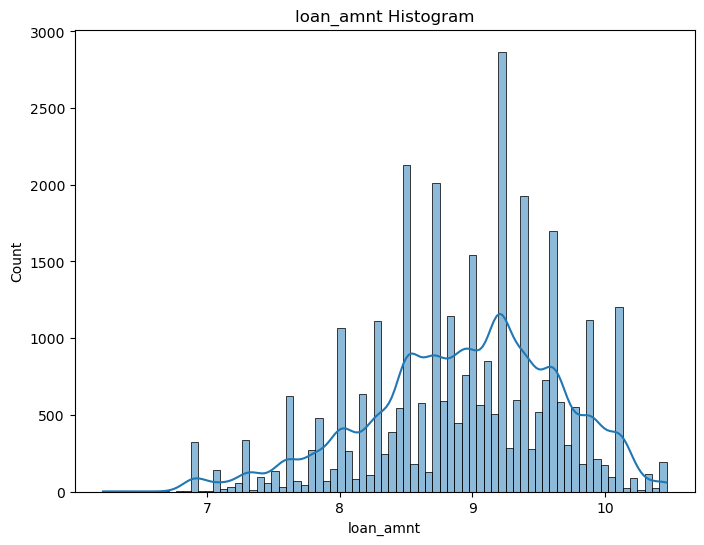

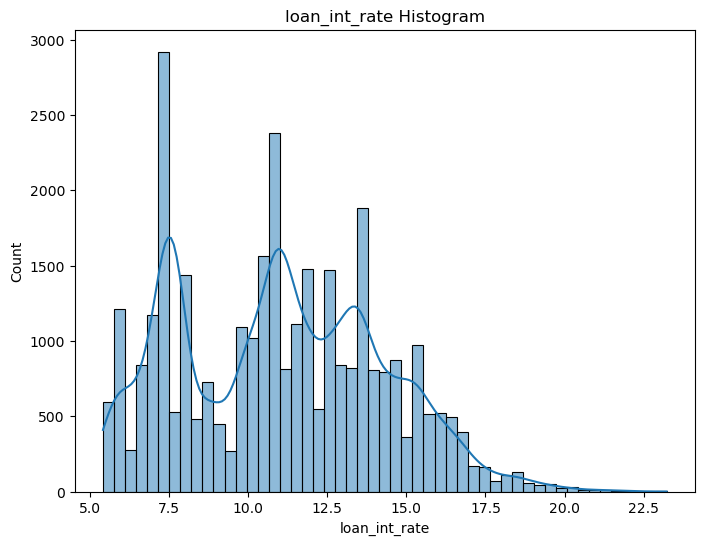

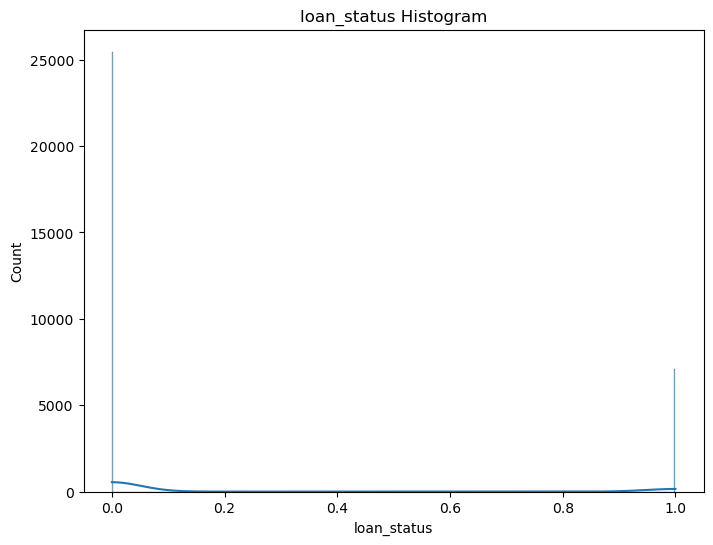

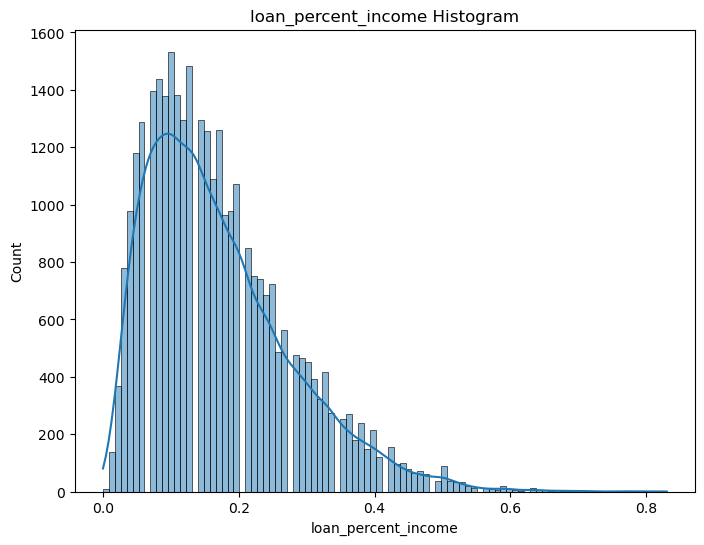

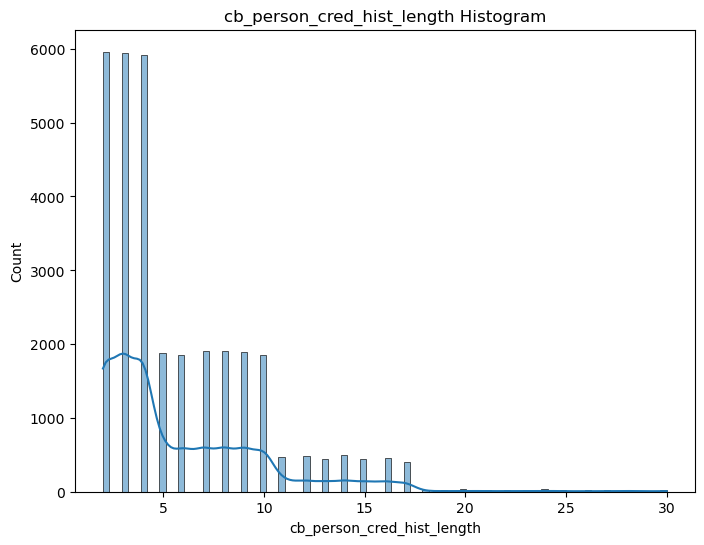

In [21]:
for i in numeric_cols :
  plt.figure(figsize=(8,6))
  sns.histplot(df[i],kde=True)
  plt.title(f"{i} Histogram")

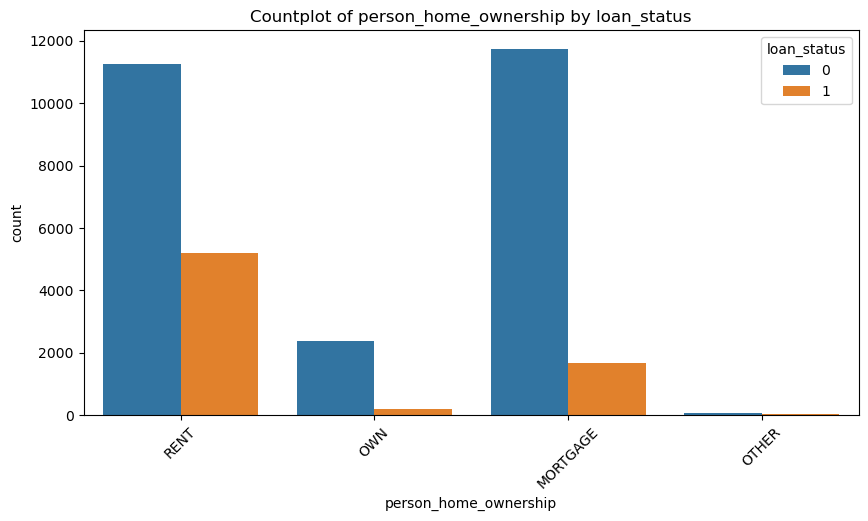

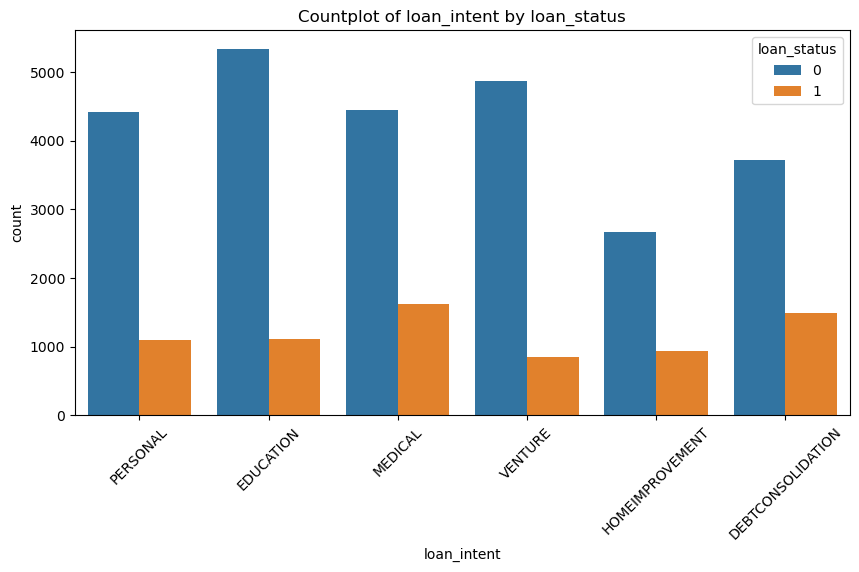

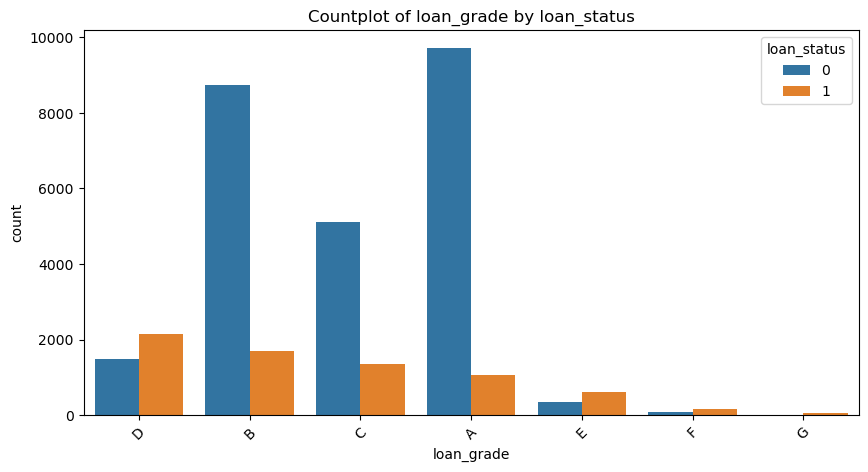

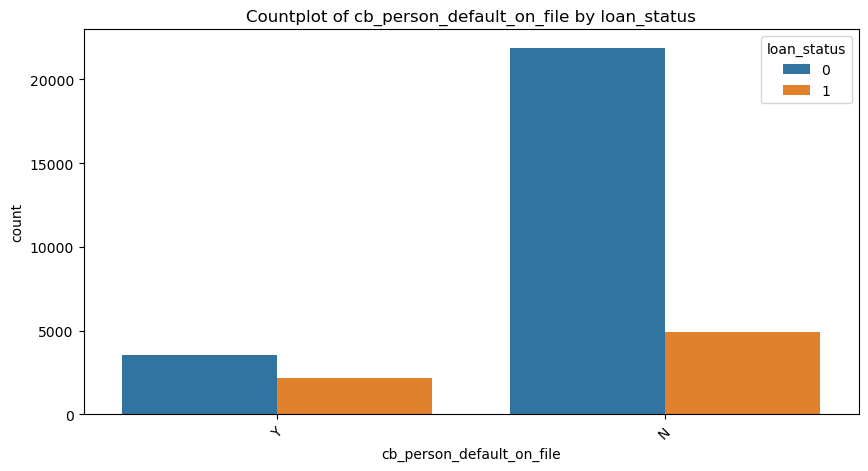

In [22]:
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(x=col, hue='loan_status', data=df)
    plt.title(f'Countplot of {col} by loan_status')
    plt.xticks(rotation=45)
    plt.show()

Text(0.5, 1.0, 'Correlation Matrix')

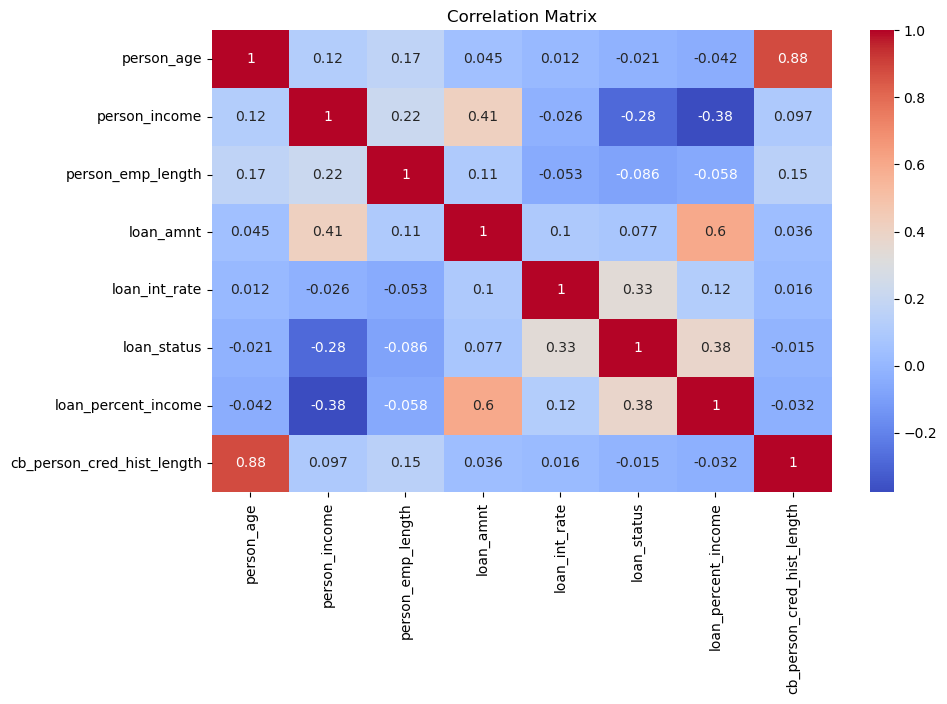

In [23]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

## 4. Feature Engineering

Created domain-informed features to improve model signal:

| Feature | Formula | Intuition |
|---|---|---|
| `income_after_loan` | `income - loan_amnt` | Net financial buffer |
| `interest_burden` | `rate × loan / income` | Repayment pressure |
| `risk_score` | `loan_pct_income + interest_burden + 1/(cred_hist+1)` | Composite risk indicator |

In [24]:
df['income_after_loan'] = df['person_income'] - df['loan_amnt']
df['interest_burden'] = df['loan_int_rate'] * df['loan_amnt'] / df['person_income']

In [25]:
df['risk_score'] = ( df['loan_percent_income'] + df['interest_burden'] + (1 / (df['cb_person_cred_hist_length'] + 1)) )

Text(0.5, 1.0, 'Correlation Matrix')

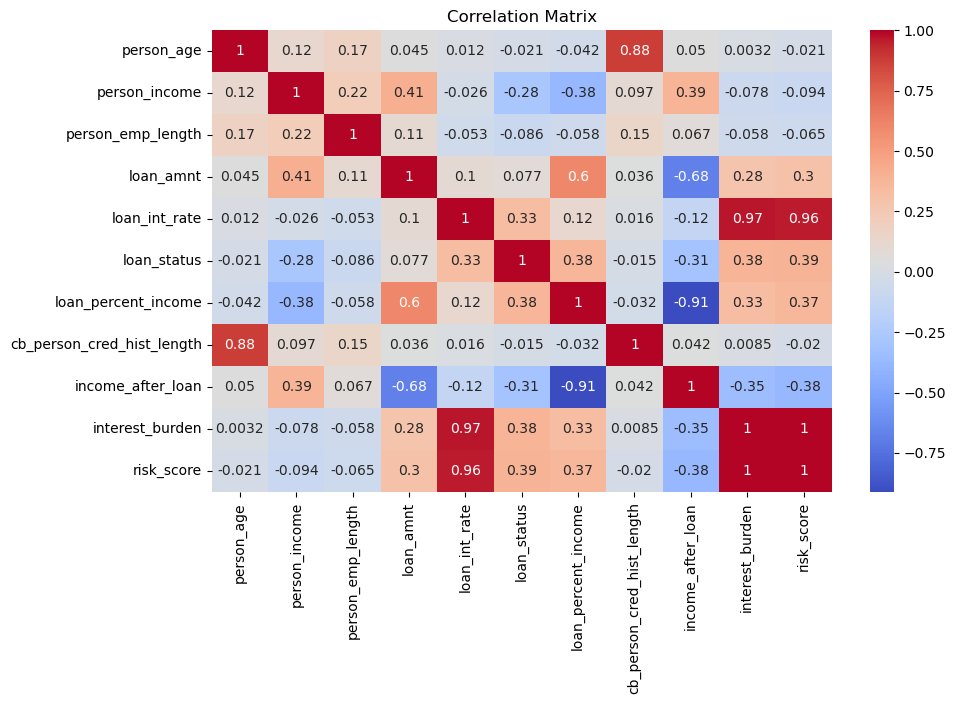

In [26]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")

## 5. Encoding

**Categorical Encoding:**
- `person_home_ownership`, `loan_intent` → **One-Hot Encoding** (nominal, no order)
- `loan_grade` → **Ordinal Mapping** (A=7 → G=1, reflects creditworthiness order)
-  `age_group` → **Ordinal Mapping** (young=0 → old=4, reflects creditworthiness order)
- `cb_person_default_on_file` → **Binary Mapping** (Y=1, N=0)



In [27]:
cat_cols = df.select_dtypes(include='object').columns
cat_cols

Index(['person_home_ownership', 'loan_intent', 'loan_grade',
       'cb_person_default_on_file'],
      dtype='object')

In [28]:
age_map={
    'Young': 0,
    'Early_Adult': 1,
    'Mid_Adult': 2,
    'Senior': 3,
    'Old': 4
}
df['age_group']=df['age_group'].map(age_map).astype('int64')

In [29]:
print(df['age_group'].dtype)

int64


In [30]:
df = pd.get_dummies(df, columns=['person_home_ownership','loan_intent'], drop_first=True)

In [31]:
grade_map = {
    'A': 7,
    'B': 6,
    'C': 5,
    'D': 4,
    'E': 3,
    'F': 2,
    'G': 1
}

df['loan_grade'] = df['loan_grade'].map(grade_map)

In [32]:
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'Y': 1, 'N': 0})

In [33]:
df=df.drop('person_age',axis=1)

## 6. Spliting And Scaling 



**Train/Test Split:** 80/20 with stratification on `loan_status`

**Scaling:** `RobustScaler` applied to training data only (fit on train, transform on both)  
> Used for distance/gradient-sensitive models (LR, SVM, KNN)

In [34]:
x = df.drop('loan_status', axis=1)
y = df['loan_status']

In [35]:
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

In [36]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
joblib.dump(scaler, 'robust_scaler.pkl')

['robust_scaler.pkl']

## 6. Model Training & Comparison

Trained and evaluated **6 models** with consistent metrics:

| Model | Notes |
|---|---|
| Logistic Regression | Baseline linear model |
| K-Nearest Neighbors | Distance-based, scaled input |
| SVM | Kernel-based, scaled input |
| Random Forest | Ensemble, no scaling needed |
| Gradient Boosting | Sequential ensemble |
| XGBoost | Gradient boosting with regularization |

**Evaluation Metrics:** Accuracy · F1-Score · ROC-AUC · Confusion Matrix  
Models requiring scaling (LR, KNN, SVM) were trained on `X_train_scaled`.

In [37]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True,random_state=42),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=5
    )
}

In [38]:
results = []
y_preds   = {}
y_probas  = {}

for name, model in models.items():
    if name in ["Logistic Regression", "SVM", "KNN","Random Forest","Gradient Boosting","XGBoost"]:
        model.fit(X_train_scaled, y_train)
        y_pred  = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    
    y_preds[name]  = y_pred
    y_probas[name] = y_proba

    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_proba)
    results.append([name, acc, f1, roc])

results_df = pd.DataFrame(
    results, columns=["Model", "Accuracy", "F1", "ROC-AUC"]
)
print(results_df.sort_values("ROC-AUC", ascending=False))

                 Model  Accuracy        F1   ROC-AUC
5              XGBoost  0.934766  0.833137  0.948953
1        Random Forest  0.930315  0.818109  0.928862
2    Gradient Boosting  0.920645  0.794270  0.926538
4                  SVM  0.910514  0.760771  0.898438
0  Logistic Regression  0.859248  0.623099  0.868587
3                  KNN  0.890714  0.712207  0.865303



================ Logistic Regression ================

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.95      0.91      5093
           1       0.75      0.53      0.62      1422

    accuracy                           0.86      6515
   macro avg       0.81      0.74      0.77      6515
weighted avg       0.85      0.86      0.85      6515



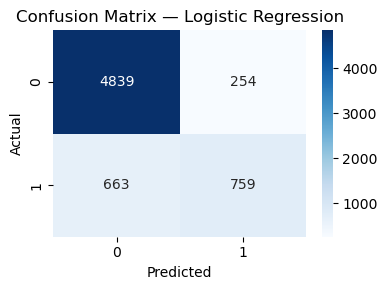


================ Random Forest ================

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5093
           1       0.95      0.72      0.82      1422

    accuracy                           0.93      6515
   macro avg       0.94      0.85      0.89      6515
weighted avg       0.93      0.93      0.93      6515



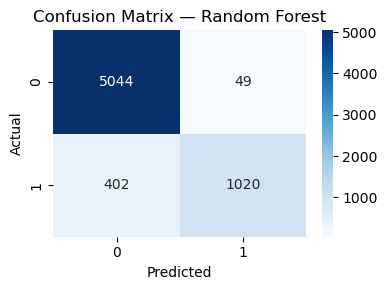


================ Gradient Boosting ================

Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.98      0.95      5093
           1       0.91      0.70      0.79      1422

    accuracy                           0.92      6515
   macro avg       0.91      0.84      0.87      6515
weighted avg       0.92      0.92      0.92      6515



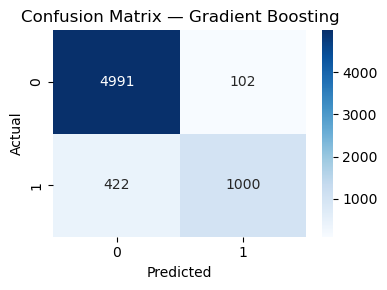


================ KNN ================

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.97      0.93      5093
           1       0.84      0.61      0.71      1422

    accuracy                           0.89      6515
   macro avg       0.87      0.79      0.82      6515
weighted avg       0.89      0.89      0.88      6515



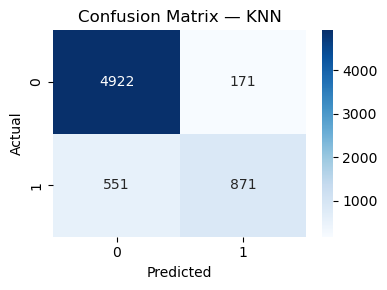


================ SVM ================

Classification Report:

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      5093
           1       0.91      0.65      0.76      1422

    accuracy                           0.91      6515
   macro avg       0.91      0.82      0.85      6515
weighted avg       0.91      0.91      0.90      6515



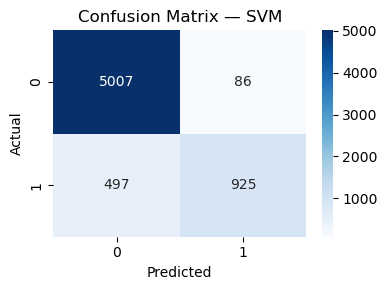


================ XGBoost ================

Classification Report:

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5093
           1       0.94      0.74      0.83      1422

    accuracy                           0.93      6515
   macro avg       0.94      0.87      0.89      6515
weighted avg       0.93      0.93      0.93      6515



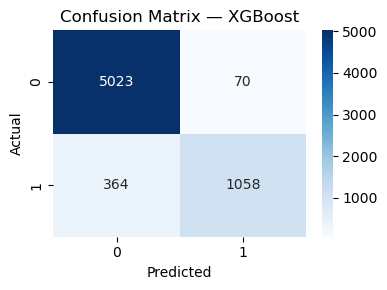

In [22]:
for name in models:
    print(f"\n{'='*16} {name} {'='*16}\n")

    print("Classification Report:\n")
    print(classification_report(y_test, y_preds[name]))

    cm = confusion_matrix(y_test, y_preds[name])
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix — {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.show()

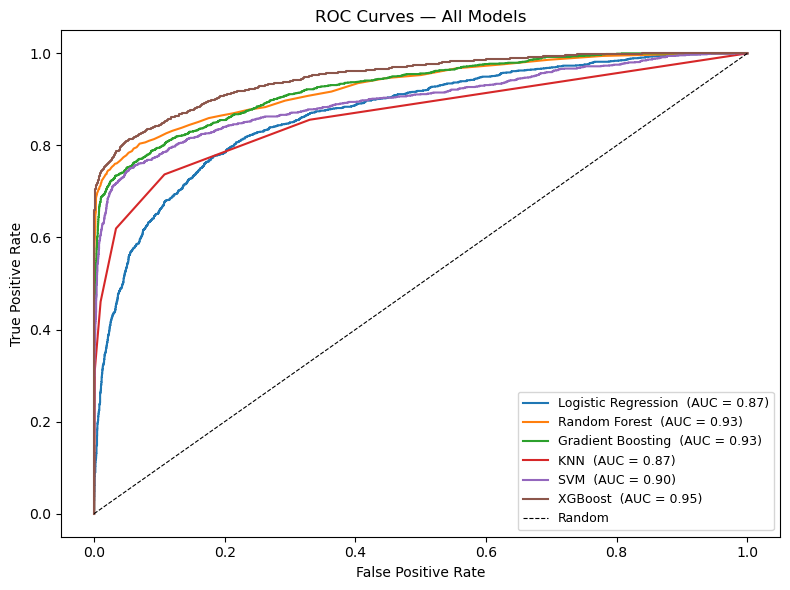

In [39]:
plt.figure(figsize=(8, 6))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, y_probas[name])
    roc_auc     = roc_auc_score(y_test, y_probas[name])
    plt.plot(fpr, tpr, label=f'{name}  (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — XGBoost

XGBoost was selected for tuning based on its strong baseline performance.

**Search Strategy:** `GridSearchCV` with 5-fold cross-validation  
**Scoring Metric:** F1-Score (prioritizes correct default detection)

**Tuned Parameters:**
- `n_estimators`: [100, 200, 300]
- `max_depth`: [3, 5, 7]
- `learning_rate`: [0.01, 0.05, 0.1]
- `subsample`: [0.7, 0.8, 1.0]
- `colsample_bytree`: [0.7, 0.8, 1.0]

**Best Parameters:** `n_estimators=200`, `max_depth=7`, `learning_rate=0.1`, `subsample=0.8`, `colsample_bytree=0.8`

In [40]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring='recall',   
    cv=5,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(X_train_scaled, y_train)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.7}
0.7383032461399823


In [41]:
best_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss'
)

best_xgb.fit(X_train_scaled, y_train)
y_pred = best_xgb.predict(X_test_scaled)

In [42]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5093
           1       0.95      0.74      0.83      1422

    accuracy                           0.93      6515
   macro avg       0.94      0.87      0.90      6515
weighted avg       0.94      0.93      0.93      6515



In [43]:
confusion_matrix(y_test, y_pred)

array([[5037,   56],
       [ 368, 1054]])

## 8. Handling Class Imbalance — SMOTE

The dataset is **imbalanced** (more non-defaults than defaults).  
Applied **SMOTE (Synthetic Minority Over-sampling Technique)** on the training set only to avoid data leakage.

Trained XGBoost on the SMOTE-resampled data and compared results against the tuned model.

> ⚠️ SMOTE was applied **after** the train/test split to prevent leakage into evaluation.

In [44]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
smote_x,smote_y=smote.fit_resample(X_train_scaled,y_train)

In [45]:
xgb = XGBClassifier(
    random_state=42,
    eval_metric='logloss'
)
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb_grid = GridSearchCV(
    estimator=xgb,
    param_grid=xgb_params,
    scoring='recall',   
    cv=5,
    n_jobs=-1,
    verbose=1
)
xgb_grid.fit(smote_x, smote_y)

print(xgb_grid.best_params_)
print(xgb_grid.best_score_)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}
0.9163677247004045


In [52]:
xgb_smote =  XGBClassifier(
        n_estimators=300,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=1.0,
    random_state=42,
    eval_metric='logloss'
    )

xgb_smote.fit(smote_x, smote_y)
y_pred_smote = xgb_smote.predict(X_test_scaled)


In [53]:
print(classification_report(y_test, y_pred_smote))

              precision    recall  f1-score   support

           0       0.93      0.99      0.96      5093
           1       0.95      0.74      0.83      1422

    accuracy                           0.93      6515
   macro avg       0.94      0.86      0.90      6515
weighted avg       0.94      0.93      0.93      6515



In [54]:
confusion_matrix(y_test,y_pred_smote)

array([[5035,   58],
       [ 370, 1052]])

## 9. Saving Best Model

In [55]:
import joblib

joblib.dump(best_xgb, 'xgboost_credit_risk.pkl')

['xgboost_credit_risk.pkl']

## Conclusion & Model Selection

### ✅ Selected Model: XGBoost (Tuned)

After comparing all models on Accuracy, F1-Score, and ROC-AUC, **XGBoost with hyperparameter tuning** was selected as the final model.

**Why XGBoost?**
- Highest ROC-AUC score across all tested models
- Strong F1 performance on the minority class (defaulters)
- Built-in regularization reduces overfitting
- Handles missing values and feature interactions well


**Key Takeaways:**
- Log transformation of skewed features improved model performance
- Domain-driven feature engineering (risk score, interest burden) added predictive signal
- SMOTE improved recall on the minority class but tuned XGBoost remained more balanced overall